In [1]:
import matplotlib.colors as mcolors
from scipy.integrate import quad
import matplotlib.pyplot as plt
from main_funcs import *
import matplotlib as mpl
import numpy as np
import pickle

In [2]:
base_dirs = {
    "Without": Path("data/Without EDM"),
    "With": Path("data/With EDM"),
    "Without New": Path("data/Without EDM NEW"),
    "With New": Path("data/With EDM NEW")
}

data_all = load_array_data(base_dirs)

In [3]:
def theta_max(lam,gamma=29.303431969091314):
    return np.arcsin(np.sqrt(lam*(1-lam))/(gamma*lam))

In [4]:
N = 10000

theta = data_all["With New"][0]["Y"][:, 0]
lambdas = data_all["With New"][0]["X"][0, :]

lambda_curr = 0.45
i_lambda = np.argmin(np.abs(lambdas - lambda_curr))

w_cma = np.load("C:/Users/JakeS/Documents/Masters Project/mphys-masters-project/Weight_Maps2/optimal_weight_lam=0.45_budget=2040.npz", allow_pickle=True)
w_cma = w_cma["weight"][:,i_lambda]

w0 = np.ones_like(theta)

num_sum = np.zeros_like(theta, dtype=float)
den_sum = np.zeros_like(theta, dtype=float)

for run_id, grids in data_all["With New"].items():
    Zcol = grids["Z"][:, i_lambda]
    p = N * Zcol * 1e-3

    A = np.sum(p * w0)
    B = np.sum(p * w0 * theta)
    C = np.sum(p * w0 * theta**2)
    D = np.sum(p * w0**2)

    y  = B / A
    s2 = C / A - (B / A)**2
    sigma2 = s2 * D / A**2

    Delta = theta - y
    a = Delta - (y * Delta**2)/(2 * s2) + 1.5 * y

    b = (y * A) / D

    weight = (y * p) / sigma2
    num_sum += weight * a
    den_sum += weight * b
    
eps = 1e-30
mask = den_sum > eps

w_opt = np.zeros_like(theta, dtype=float)
w_opt[mask] = num_sum[mask] / den_sum[mask]

w_opt = np.maximum(0.0, w_opt)

In [5]:
a = theta_max(lambdas[i_lambda])*1e3
b = abs(theta[np.nanargmax(w_opt)])
c = np.abs(a-b)/a * 100
print(a,b,c)

37.728690194352076 37.27454909819642 1.2037022589870972


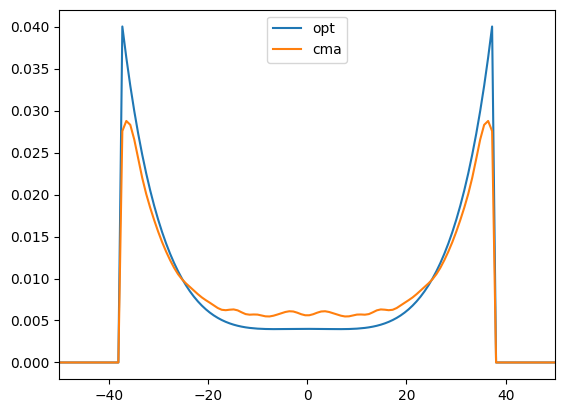

In [6]:
w_cma = np.load("C:/Users/JakeS/Documents/Masters Project/mphys-masters-project/Weight_Maps2/optimal_weight_lam=0.45_budget=2040.npz", allow_pickle=True)

plt.plot(theta,w_opt/np.sum(w_opt),label="opt")
plt.plot(theta,w_cma["weight"][:,i_lambda]/np.sum(w_cma["weight"][:,i_lambda]),label="cma")
plt.legend()
plt.xlim([-50,50])
plt.show()

In [7]:
FOM_opt = compute_fom_for_lambda(data_all,N,0.45,weight_func=lambda Y,X: np.tile(w_opt[:, None], (1, X.shape[1])))
FOM_cma = compute_fom_for_lambda(data_all,N,0.45,weight_func=lambda Y,X: w_cma["weight"])
print(FOM_opt['FOM']/FOM_cma['FOM'], FOM_cma['FOM']/FOM_cma['FOM'])

0.965633916284561 1.0


In [70]:
def weight_per_lam(lam, w0=np.ones_like(theta), N=1e5):
    i_lambda = np.argmin(np.abs(lambdas - lam))

    num_sum = np.zeros_like(theta, dtype=float)
    den_sum = np.zeros_like(theta, dtype=float)

    for run_id, grids in data_all["With New"].items():
        Zcol = grids["Z"][:, i_lambda]
        p = N * Zcol * 1e-3

        A = np.sum(p * w0)
        B = np.sum(p * w0 * theta)
        C = np.sum(p * w0 * theta**2)
        D = np.sum(p * w0**2)

        y  = B / A
        s2 = C / A - (B / A)**2
        sigma2 = s2 * D / A**2

        Delta = theta - y
        a = Delta - (y * Delta**2)/(2 * s2) + 1.5 * y

        b = (y * A) / D

        weight = (y * p) / sigma2
        num_sum += weight * a
        den_sum += weight * b
        
    eps = 1e-30
    mask = den_sum > eps

    w_opt = np.zeros_like(theta, dtype=float)
    w_opt[mask] = num_sum[mask] / den_sum[mask]

    # w_opt = np.maximum(0.0, w_opt)
    return w_opt

In [94]:
w_tot = []

w_cma_full = np.load("total_interpolated_weights.npz", allow_pickle=True)

for lam in lambdas:
    i_lambda = np.argmin(np.abs(lambdas - lam))
    w0_curr = w_cma_full["weight"][:,i_lambda]
    w_curr = weight_per_lam(lam)#,w0=w0_curr)
    w_tot.append(w_curr)

C:\Users\JakeS\AppData\Local\Temp\ipykernel_54604\1794199109.py:16: RuntimeWarning: invalid value encountered in scalar divide
  y  = B / A
C:\Users\JakeS\AppData\Local\Temp\ipykernel_54604\1794199109.py:17: RuntimeWarning: invalid value encountered in scalar divide
  s2 = C / A - (B / A)**2


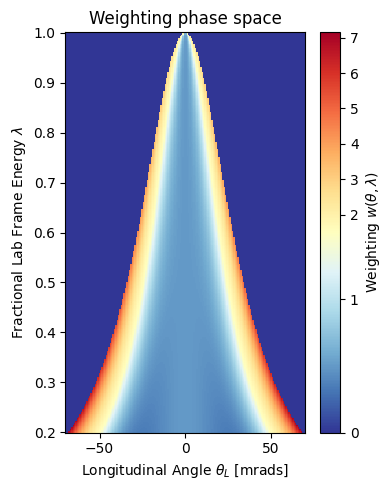

In [ ]:
X = data_all["With New"][0]["X"]
Y = data_all["With New"][0]["Y"]
Z = data_all["With New"][0]["Z"]

w_tot = np.array(w_tot)

cmap = plt.get_cmap("RdYlBu_r")
norm = mcolors.TwoSlopeNorm(
    vmin=w_tot.min(),
    vcenter=1.5,   # physics-dominant region
    vmax=w_tot.max()
)

np.savez_compressed("analytic_weights_cma_lead.npz",weight=w_tot)

fig2, ax2 = plt.subplots(figsize=(4, 5))
c = ax2.pcolormesh(Y, X, w_tot.T, shading="auto",cmap=cmap, norm=norm, rasterized=True)
ax2.set_ylabel(r"Fractional Lab Frame Energy $\lambda$")
ax2.set_xlabel(r"Longitudinal Angle $\theta_L$ [mrads]")
ax2.set_title("Weighting phase space")
# ax2.set_facecolor("#F7F9FC")
# fig2.set_facecolor("#F7F9FC")
ax2.set_xlim([-70,70])
fig2.colorbar(c, ax=ax2, label=r"Weighting $w(\theta,\lambda)$")
fig2.tight_layout()
# plt.savefig("phd interview/weighting phase space.png")
plt.show()

In [96]:
w_cma_tot = np.load("full_weight_map_interpolated.npz")["weight"]

cma_FOM = compute_fom_over_lambda(data_all,1e6,weight_func=lambda Y,X: w_cma["weight"])
analytic_FOM = compute_fom_over_lambda(data_all,1e6,weight_func=lambda Y,X: w_tot.T)
unweighted_FOM = compute_fom_over_lambda(data_all,1e6,weight_func=lambda Y,X: np.ones_like(w_tot))

In [97]:
print(np.nansum(analytic_FOM)/np.nansum(unweighted_FOM))

1.4487662002406885
